# Satellite Damage Assessment: Feature Engineering

## Notebook 2 - Patch Creation & Dataset Preparation

This notebook:
1. Loads cleaned Sentinel-2 scenes and spectral indices
2. Optionally aggregates scenes to yearly composites
3. Creates image patches (if USE_PATCHES=True) or scene-level rows
4. Computes statistical features per patch/scene
5. Creates train/val/test dataset splits
6. Saves everything ready for Notebook 2b (optional) and Notebook 3

## 0. Configuration

**Change these settings to switch between modes. Everything downstream adapts automatically.**

In [1]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                     PIPELINE CONFIGURATION                         ║
# ╠══════════════════════════════════════════════════════════════════════╣

# Temporal resolution: 'yearly' or 'quarterly'
#   yearly    → scenes aggregated per city per year (fewer, less RAM)
#   quarterly → scenes kept at quarterly granularity (more temporal detail)
TEMPORAL_RESOLUTION = 'yearly'

# Patch mode: True = create image patches, False = scene-level features only
#   True  → saves .npy patch files, more data, needs more RAM & disk
#   False → one row per scene/year, fast, compatible with Notebook 2b
USE_PATCHES = False

# Patch settings (only used when USE_PATCHES = True)
PATCH_SIZE = 128
PATCH_STRIDE = 128   # smaller stride = more patches & more overlap

# Train / val / test split ratios (must sum to 1.0)
TEST_SIZE  = 0.30
VAL_SIZE   = 0.25   # fraction of the remaining train set

RANDOM_SEED = 42

# ╚══════════════════════════════════════════════════════════════════════╝

print('=' * 70)
print('PIPELINE CONFIGURATION')
print('=' * 70)
print(f'  Temporal resolution : {TEMPORAL_RESOLUTION}')
print(f'  Use patches         : {USE_PATCHES}')
if USE_PATCHES:
    print(f'  Patch size          : {PATCH_SIZE}x{PATCH_SIZE}')
    print(f'  Patch stride        : {PATCH_STRIDE}')
print(f'  Split (test/val)    : {TEST_SIZE} / {VAL_SIZE}')
print(f'  Random seed         : {RANDOM_SEED}')

PIPELINE CONFIGURATION
  Temporal resolution : yearly
  Use patches         : False
  Split (test/val)    : 0.3 / 0.25
  Random seed         : 42


## 1. Setup & Load Data

In [2]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

# Setup output directories
os.makedirs('../data/splits', exist_ok=True)
os.makedirs('../data/patches', exist_ok=True)
os.makedirs('../results/plots', exist_ok=True)

# Load cleaned metadata from Notebook 1
df_indices = pd.read_csv('../data/processed/sentinel2_clean_2021_2024.csv')

print('Data Loaded')
print(f'  Scenes : {len(df_indices)}')
print(f'  Cities : {df_indices["city"].nunique()}')
print(f'  Years  : {sorted(df_indices["year"].unique())}')
if 'quarter' in df_indices.columns:
    print(f'  Quarters available: yes')
print()
print(df_indices.head())

Data Loaded
  Scenes : 39
  Cities : 3
  Years  : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  Quarters available: yes

                                    filename      city   period  year quarter  \
0  ../data/raw/S2_2021_Q1_Mariupol_clean.npy  Mariupol  2021_Q1  2021      Q1   
1  ../data/raw/S2_2021_Q2_Mariupol_clean.npy  Mariupol  2021_Q2  2021      Q2   
2  ../data/raw/S2_2021_Q3_Mariupol_clean.npy  Mariupol  2021_Q3  2021      Q3   
3  ../data/raw/S2_2021_Q4_Mariupol_clean.npy  Mariupol  2021_Q4  2021      Q4   
4  ../data/raw/S2_2022_Q1_Mariupol_clean.npy  Mariupol  2022_Q1  2022      Q1   

   cloud_cover_pct  ndvi_mean  ndvi_std  ndvi_min  ndvi_max  ndbi_mean  \
0         1.579593  -0.453026  0.596125 -0.996055  0.983870   0.109403   
1        19.394487   0.116655  0.408689 -0.495601  0.964457  -0.206263   
2         0.462978  -0.012504  0.460326 -1.000000  0.999975  -0.318961   
3        17.163327  -0.314803  0.542575 -1.000000  1.000000   0.205979   
4

## 2. Temporal Aggregation

If `TEMPORAL_RESOLUTION = 'yearly'`, scenes from the same city and year are
collapsed into a single composite row by averaging their spectral index columns.
The underlying `.npy` file used is the one with the lowest cloud cover for that
city-year combination (best available scene).

If `TEMPORAL_RESOLUTION = 'quarterly'`, this cell is a no-op and the original
rows are kept as-is.

In [3]:
if TEMPORAL_RESOLUTION == 'yearly':
    print('Aggregating scenes to yearly composites...')

    # Numeric columns to average across scenes within the same city-year
    numeric_cols = df_indices.select_dtypes(include=[np.number]).columns.tolist()
    # Exclude year itself and any id columns from averaging
    avg_cols = [c for c in numeric_cols if c not in ['year', 'patch_id']]

    # For each city-year, pick the representative .npy file:
    # prefer lowest cloud cover; fall back to first available
    # def pick_best_scene(group):
    #     if 'cloud_cover_pct' in group.columns:
    #         return group.loc[group['cloud_cover_pct'].idxmin(), 'filename']
    #     return group.iloc[0]['filename']
    
    def pick_best_scene(group):
        if 'cloud_cover_pct' in group.columns:
            # Prefer Q2/Q3 (spring/summer) for consistent phenology, then fallback to lowest cloud
            preferred = group[group['quarter'].isin(['Q2', 'Q3'])]
            pool = preferred if len(preferred) > 0 else group
            return pool.loc[pool['cloud_cover_pct'].idxmin(), 'filename']
        return group.iloc[0]['filename']

    best_files = (
        df_indices.groupby(['city', 'year'])
        .apply(pick_best_scene)
        .reset_index()
        .rename(columns={0: 'filename'})
    )

    # Average numeric features
    agg_dict = {c: 'mean' for c in avg_cols if c in df_indices.columns}
    df_yearly = (
        df_indices.groupby(['city', 'year'])
        .agg(agg_dict)
        .reset_index()
    )

    # Attach the best representative filename
    df_yearly = df_yearly.merge(best_files, on=['city', 'year'], how='left')

    # Add a period column consistent with the quarterly format (e.g. '2022_annual')
    df_yearly['period'] = df_yearly['year'].astype(str) + '_annual'

    df_scenes = df_yearly.copy()

    print(f'  Original scenes : {len(df_indices)}')
    print(f'  Yearly composites: {len(df_scenes)}')
    print(f'  Cities x Years  : {df_scenes[["city","year"]].drop_duplicates().shape[0]}')

else:  # quarterly — keep as-is
    df_scenes = df_indices.copy()
    # Ensure a period column exists
    if 'period' not in df_scenes.columns:
        if 'quarter' in df_scenes.columns:
            df_scenes['period'] = df_scenes['year'].astype(str) + '_Q' + df_scenes['quarter'].astype(str)
        else:
            df_scenes['period'] = df_scenes['year'].astype(str)

    print(f'Keeping quarterly resolution: {len(df_scenes)} scenes')

print()
print(df_scenes[['city', 'year', 'period', 'filename']].head(10).to_string(index=False))

Aggregating scenes to yearly composites...
  Original scenes : 39
  Yearly composites: 12
  Cities x Years  : 12

    city  year      period                                  filename
 Bakhmut  2021 2021_annual  ../data/raw/S2_2021_Q3_Bakhmut_clean.npy
 Bakhmut  2022 2022_annual  ../data/raw/S2_2022_Q2_Bakhmut_clean.npy
 Bakhmut  2023 2023_annual  ../data/raw/S2_2023_Q3_Bakhmut_clean.npy
 Bakhmut  2024 2024_annual  ../data/raw/S2_2024_Q2_Bakhmut_clean.npy
 Kharkiv  2021 2021_annual  ../data/raw/S2_2021_Q2_Kharkiv_clean.npy
 Kharkiv  2022 2022_annual  ../data/raw/S2_2022_Q2_Kharkiv_clean.npy
 Kharkiv  2023 2023_annual  ../data/raw/S2_2023_Q3_Kharkiv_clean.npy
 Kharkiv  2024 2024_annual  ../data/raw/S2_2024_Q2_Kharkiv_clean.npy
Mariupol  2021 2021_annual ../data/raw/S2_2021_Q3_Mariupol_clean.npy
Mariupol  2022 2022_annual ../data/raw/S2_2022_Q3_Mariupol_clean.npy


## 3. Create Damage Labels

In [4]:
# 0 = Not damaged (2021 baseline)
# 1 = Damaged     (2022-2024 conflict period)

df_scenes['damage_label'] = (df_scenes['year'] >= 2022).astype(int)

# Damage score: high when NDVI is low and NDBI is high
if 'ndvi_mean' in df_scenes.columns and 'ndbi_mean' in df_scenes.columns:
    df_scenes['damage_score'] = (1 - df_scenes['ndvi_mean']) * df_scenes['ndbi_mean']
else:
    df_scenes['damage_score'] = 0.0

print('Damage Labels:')
print(f'  0 (Not damaged): {(df_scenes["damage_label"] == 0).sum()} scenes')
print(f'  1 (Damaged):     {(df_scenes["damage_label"] == 1).sum()} scenes')
print(f'Damage Score Range: [{df_scenes["damage_score"].min():.3f}, {df_scenes["damage_score"].max():.3f}]')

# Per-city breakdown
print()
print('Per-city label counts:')
print(df_scenes.groupby(['city', 'damage_label']).size().unstack(fill_value=0).to_string())

Damage Labels:
  0 (Not damaged): 3 scenes
  1 (Damaged):     9 scenes
Damage Score Range: [-0.088, 0.027]

Per-city label counts:
damage_label  0  1
city              
Bakhmut       1  3
Kharkiv       1  3
Mariupol      1  3


## 4. Feature Extraction Functions

In [5]:
def compute_patch_features(image):
    """
    Compute spectral index statistics from a raw image array.
    Works for both full scenes and 128x128 patches.
    Expects bands in order: [Blue, Green, Red, NIR, SWIR1, SWIR2, ...]
    """
    features = {}

    red  = image[..., 2].astype(float)
    nir  = image[..., 3].astype(float)
    ndvi = (nir - red) / (nir + red + 1e-8)
    features['ndvi_mean'] = float(np.nanmean(ndvi))
    features['ndvi_std']  = float(np.nanstd(ndvi))

    swir = image[..., 4].astype(float)
    ndbi = (swir - nir) / (swir + nir + 1e-8)
    features['ndbi_mean'] = float(np.nanmean(ndbi))
    features['ndbi_std']  = float(np.nanstd(ndbi))

    blue = image[..., 0].astype(float)
    bsi  = (swir + red - nir - blue) / (swir + red + nir + blue + 1e-8)
    features['bsi_mean'] = float(np.nanmean(bsi))
    features['bsi_std']  = float(np.nanstd(bsi))

    # Derived damage proxy
    features['damage_score'] = float((1 - features['ndvi_mean']) * features['ndbi_mean'])

    return features


def create_patches(image, patch_size=128, stride=64):
    """
    Slice a 2D/3D image into overlapping patches of size patch_size x patch_size.
    Returns a list of patches and a list of (row, col) origin dicts.
    """
    h, w = image.shape[:2]
    patches   = []
    patch_info = []

    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            patches.append(image[i:i + patch_size, j:j + patch_size])
            patch_info.append({'row': i, 'col': j})

    return patches, patch_info


print('✓ Feature extraction functions defined')
print(f'  compute_patch_features → 7 features (ndvi/ndbi/bsi mean+std + damage_score)')
print(f'  create_patches         → {PATCH_SIZE}x{PATCH_SIZE} patches, stride={PATCH_STRIDE}')

✓ Feature extraction functions defined
  compute_patch_features → 7 features (ndvi/ndbi/bsi mean+std + damage_score)
  create_patches         → 128x128 patches, stride=128


## 5. Build Dataset

Branches on `USE_PATCHES`:
- **True**  → load each `.npy` scene, slice into patches, compute features per patch
- **False** → one row per scene using pre-computed index columns from the CSV

In [6]:
all_metadata = []
patch_counter = 0

if USE_PATCHES:
    print(f'Creating {PATCH_SIZE}x{PATCH_SIZE} patches (stride={PATCH_STRIDE}) from all scenes...\n')

    for idx, row in df_scenes.iterrows():
        filepath = row.get('filename', None)
        if not filepath or not os.path.exists(str(filepath)):
            print(f'  ⚠ SKIP  {row["city"]:10} {row["period"]} — file not found')
            continue

        try:
            image = np.load(filepath)
            patches, patch_info = create_patches(image, patch_size=PATCH_SIZE, stride=PATCH_STRIDE)

            # ← NEW: Filter out NaN-corrupted patches ←
            valid_patches = []
            valid_patch_info = []
            
            for patch, info in zip(patches, patch_info):
                nan_ratio = np.isnan(patch).sum() / patch.size
                if nan_ratio < 0.2:  # Keep patches with <20% NaN
                    valid_patches.append(patch)
                    valid_patch_info.append(info)
            
            if len(valid_patches) == 0:
                print(f'  ⚠ SKIP  {row["city"]:10} {row["period"]:15} (all patches corrupted by cloud cover)')
                continue
            
            print(f'  ✓ {row["city"]:10} {row["period"]:15} → {len(valid_patches):3d} patches (filtered)')

            for patch, info in zip(valid_patches, valid_patch_info):
                # Replace any remaining NaN with 0
                patch = np.nan_to_num(patch, nan=0.0)
                
                features = compute_patch_features(patch)

                meta = {
                    'patch_id'      : patch_counter,
                    'city'          : row['city'],
                    'period'        : row['period'],
                    'year'          : row['year'],
                    'damage_label'  : row['damage_label'],
                    'patch_row'     : info['row'],
                    'patch_col'     : info['col'],
                    'temporal_res'  : TEMPORAL_RESOLUTION,
                }
                meta.update(features)
                all_metadata.append(meta)

                np.save(f'../data/patches/patch_{patch_counter:06d}.npy', patch)
                patch_counter += 1

        except Exception as e:
            print(f'  ✗ ERROR {row["city"]:10} {row["period"]} — {str(e)[:60]}')
            continue

    print(f'\n✓ Total patches created: {patch_counter}')

else:  # scene-level features (no patches)
    print('Building scene-level feature rows (no patches)...\n')

    # Columns already in the CSV that are features
    csv_feature_cols = [c for c in df_scenes.columns
                        if c.startswith(('ndvi_', 'ndbi_', 'bsi_'))]

    for idx, row in df_scenes.iterrows():
        meta = {
            'patch_id'    : idx,          # reuse patch_id name for compatibility
            'city'        : row['city'],
            'period'      : row['period'],
            'year'        : row['year'],
            'damage_label': row['damage_label'],
            'damage_score': row['damage_score'],
            'filename'    : row.get('filename', None),
            'temporal_res': TEMPORAL_RESOLUTION,
        }

        # Carry forward any spectral columns already computed in notebook 1
        for col in csv_feature_cols:
            meta[col] = row[col]

        # If the .npy scene file exists, also compute fresh per-scene features
        filepath = row.get('filename', None)
        if filepath and os.path.exists(str(filepath)):
            try:
                image = np.load(filepath)
                features = compute_patch_features(image)
                # Prefix with 'scene_' to distinguish from CSV columns
                for k, v in features.items():
                    meta[f'scene_{k}'] = v
                print(f'  ✓ {row["city"]:10} {row["period"]}')
            except Exception as e:
                print(f'  ⚠ {row["city"]:10} {row["period"]} — could not load .npy: {str(e)[:50]}')
        else:
            print(f'  ⚠ {row["city"]:10} {row["period"]} — no .npy, using CSV features only')

        all_metadata.append(meta)

    print(f'\n✓ Total scene rows: {len(all_metadata)}')

df_dataset = pd.DataFrame(all_metadata)
print(f'\nDataset shape: {df_dataset.shape}')
print(f'Columns: {df_dataset.columns.tolist()}')
print()
print(df_dataset.head())

Building scene-level feature rows (no patches)...

  ✓ Bakhmut    2021_annual
  ✓ Bakhmut    2022_annual
  ✓ Bakhmut    2023_annual
  ✓ Bakhmut    2024_annual
  ✓ Kharkiv    2021_annual
  ✓ Kharkiv    2022_annual
  ✓ Kharkiv    2023_annual
  ✓ Kharkiv    2024_annual
  ✓ Mariupol   2021_annual
  ✓ Mariupol   2022_annual
  ✓ Mariupol   2023_annual
  ✓ Mariupol   2024_annual

✓ Total scene rows: 12

Dataset shape: (12, 27)
Columns: ['patch_id', 'city', 'period', 'year', 'damage_label', 'damage_score', 'filename', 'temporal_res', 'ndvi_mean', 'ndvi_std', 'ndvi_min', 'ndvi_max', 'ndbi_mean', 'ndbi_std', 'ndbi_min', 'ndbi_max', 'bsi_mean', 'bsi_std', 'bsi_min', 'bsi_max', 'scene_ndvi_mean', 'scene_ndvi_std', 'scene_ndbi_mean', 'scene_ndbi_std', 'scene_bsi_mean', 'scene_bsi_std', 'scene_damage_score']

   patch_id     city       period  year  damage_label  damage_score  \
0         0  Bakhmut  2021_annual  2021             0     -0.088250   
1         1  Bakhmut  2022_annual  2022            

## 6. Create Train / Val / Test Splits

In [7]:
# from sklearn.model_selection import train_test_split

# # Check class balance before splitting
# label_counts = df_dataset['damage_label'].value_counts()
# print('Class balance before split:')
# print(f'  0 (Not damaged): {label_counts.get(0, 0)}')
# print(f'  1 (Damaged):     {label_counts.get(1, 0)}')
# print()

# # Stratified split: test
# df_train_full, df_test = train_test_split(
#     df_dataset,
#     test_size=TEST_SIZE,
#     random_state=RANDOM_SEED,
#     stratify=df_dataset['damage_label']
# )

# # Stratified split: train / val from remainder
# df_train, df_val = train_test_split(
#     df_train_full,
#     test_size=VAL_SIZE,
#     random_state=RANDOM_SEED,
#     stratify=df_train_full['damage_label']
# )

from sklearn.model_selection import GroupShuffleSplit

# Group by city+year so all patches from one scene stay together
groups = df_dataset['city'] + '_' + df_dataset['year'].astype(str)

gss_test = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_SEED)
train_val_idx, test_idx = next(gss_test.split(df_dataset, groups=groups))

df_train_val = df_dataset.iloc[train_val_idx]
df_test      = df_dataset.iloc[test_idx]
groups_tv    = groups.iloc[train_val_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=RANDOM_SEED)
train_idx, val_idx = next(gss_val.split(df_train_val, groups=groups_tv))

df_train = df_train_val.iloc[train_idx]
df_val   = df_train_val.iloc[val_idx]

total = len(df_dataset)
print(f'Split sizes:')
print(f'  Train : {len(df_train):>5}  ({len(df_train)/total*100:.1f}%)')
print(f'  Val   : {len(df_val):>5}  ({len(df_val)/total*100:.1f}%)')
print(f'  Test  : {len(df_test):>5}  ({len(df_test)/total*100:.1f}%)')

# Verify stratification
for name, split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    pct = split['damage_label'].mean() * 100
    print(f'  {name} damaged %: {pct:.1f}%')

# Save splits
df_train.to_csv('../data/splits/train_metadata.csv', index=False)
df_val.to_csv('../data/splits/val_metadata.csv',   index=False)
df_test.to_csv('../data/splits/test_metadata.csv',  index=False)
df_dataset.to_csv('../data/processed/patches_metadata.csv', index=False)

print()
print('✓ Splits saved to ../data/splits/')

Split sizes:
  Train :     6  (50.0%)
  Val   :     2  (16.7%)
  Test  :     4  (33.3%)
  Train damaged %: 83.3%
  Val damaged %: 100.0%
  Test damaged %: 50.0%

✓ Splits saved to ../data/splits/


## 7. Visualization

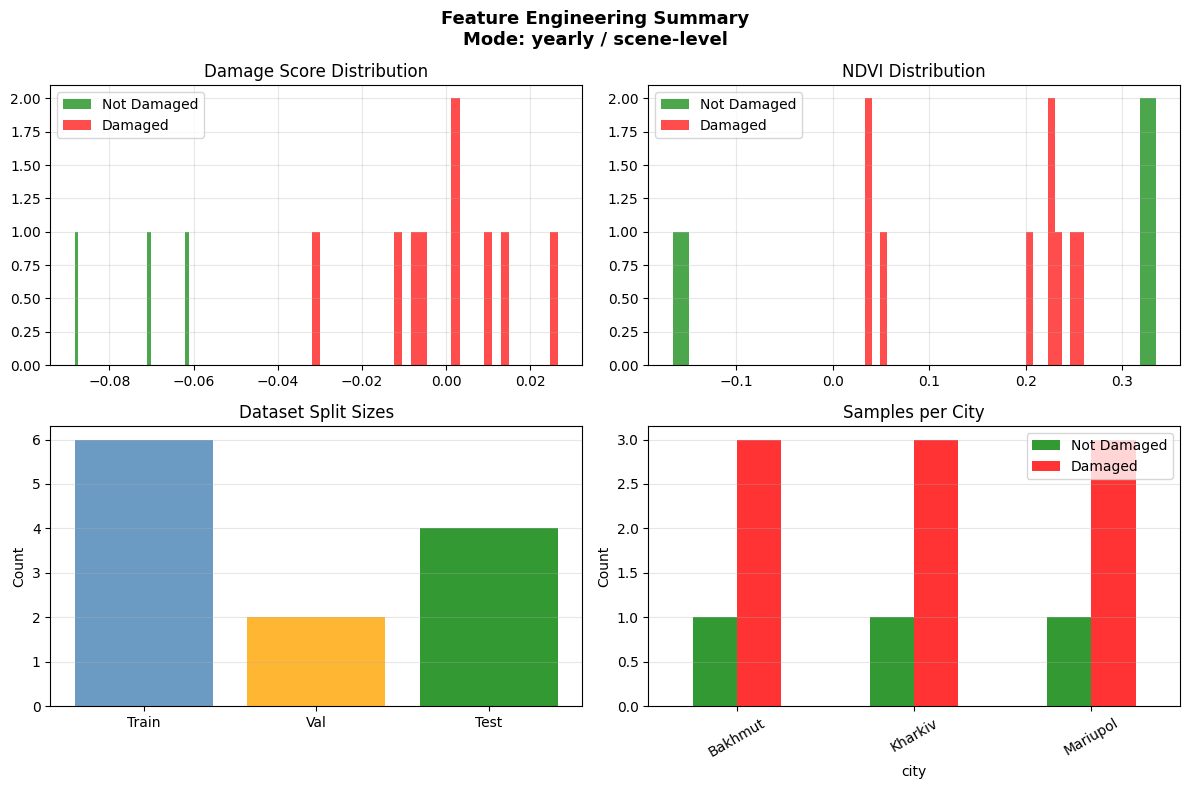

✓ Plot saved to ../results/plots/feature_engineering_yearly_scenes.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(
    f'Feature Engineering Summary\n'
    f'Mode: {TEMPORAL_RESOLUTION} / {"patches" if USE_PATCHES else "scene-level"}',
    fontsize=13, fontweight='bold'
)

# 1. Damage score distribution
score_col = 'damage_score'
if score_col in df_dataset.columns:
    axes[0, 0].hist(df_dataset[df_dataset['damage_label']==0][score_col],
                    bins=30, alpha=0.7, label='Not Damaged', color='green')
    axes[0, 0].hist(df_dataset[df_dataset['damage_label']==1][score_col],
                    bins=30, alpha=0.7, label='Damaged', color='red')
    axes[0, 0].set_title('Damage Score Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

# 2. NDVI distribution
ndvi_col = 'ndvi_mean'
if ndvi_col in df_dataset.columns:
    axes[0, 1].hist(df_dataset[df_dataset['damage_label']==0][ndvi_col],
                    bins=30, alpha=0.7, label='Not Damaged', color='green')
    axes[0, 1].hist(df_dataset[df_dataset['damage_label']==1][ndvi_col],
                    bins=30, alpha=0.7, label='Damaged', color='red')
    axes[0, 1].set_title('NDVI Distribution')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

# 3. Split sizes
axes[1, 0].bar(['Train', 'Val', 'Test'],
               [len(df_train), len(df_val), len(df_test)],
               color=['steelblue', 'orange', 'green'], alpha=0.8)
axes[1, 0].set_title('Dataset Split Sizes')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Samples per city
city_counts = df_dataset.groupby(['city', 'damage_label']).size().unstack(fill_value=0)
city_counts.plot(kind='bar', ax=axes[1, 1], color=['green', 'red'], alpha=0.8)
axes[1, 1].set_title('Samples per City')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(['Not Damaged', 'Damaged'])
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plot_name = f'feature_engineering_{TEMPORAL_RESOLUTION}_{"patches" if USE_PATCHES else "scenes"}.png'
plt.savefig(f'../results/plots/{plot_name}', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Plot saved to ../results/plots/{plot_name}')

## 8. Summary

In [9]:
print('=' * 70)
print('FEATURE ENGINEERING COMPLETE')
print('=' * 70)
print(f'  Temporal resolution : {TEMPORAL_RESOLUTION}')
print(f'  Patch mode          : {USE_PATCHES}')
if USE_PATCHES:
    print(f'  Patch size          : {PATCH_SIZE}x{PATCH_SIZE}, stride={PATCH_STRIDE}')
print()
print(f'  Total samples  : {len(df_dataset):,}')
print(f'  Train          : {len(df_train):,}')
print(f'  Val            : {len(df_val):,}')
print(f'  Test           : {len(df_test):,}')
print(f'  Feature columns: {df_dataset.shape[1]}')
print()
print('Files saved:')
print('  ../data/splits/train_metadata.csv')
print('  ../data/splits/val_metadata.csv')
print('  ../data/splits/test_metadata.csv')
print('  ../data/processed/patches_metadata.csv')
if USE_PATCHES:
    print('  ../data/patches/patch_*.npy')
print()
print('Next steps:')
print('  → Run Notebook 2b to enrich with GLCM/texture features (optional)')
print('  → Run Notebook 3 for model training')

FEATURE ENGINEERING COMPLETE
  Temporal resolution : yearly
  Patch mode          : False

  Total samples  : 12
  Train          : 6
  Val            : 2
  Test           : 4
  Feature columns: 27

Files saved:
  ../data/splits/train_metadata.csv
  ../data/splits/val_metadata.csv
  ../data/splits/test_metadata.csv
  ../data/processed/patches_metadata.csv

Next steps:
  → Run Notebook 2b to enrich with GLCM/texture features (optional)
  → Run Notebook 3 for model training
